In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils


# --- Hyperparameters ---
IMAGE_SIZE = 32
CHANNELS = 3
BATCH_SIZE = 256
NUM_FEATURES = 128
Z_DIM = 200
LEARNING_RATE = 0.0005
EPOCHS = 30
BETA = 2000  # Weight on reconstruction loss
LOAD_MODEL = False
DEVICE = "cuda"

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


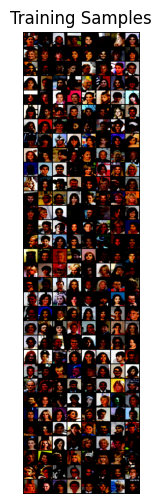

In [3]:
# Path to CelebA images
DATA_PATH = "./data/img_align_celeba/img_align_celeba"

# Transforms: resize to 32x32 and normalize to [0,1]
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),  # values in [0,1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Dataset & DataLoader
train_dataset = datasets.ImageFolder(
    root=os.path.dirname(DATA_PATH),  # Folder containing subfolder "img_align_celeba"
    transform=transform
)
# NB: If you have a specific folder structure, adjust accordingly

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    drop_last=True
)

# Utility: show a batch of faces
def show_batch(images, title=""):
    grid_img = utils.make_grid(images, nrow=8)
    plt.figure(figsize=(12, 6))
    plt.imshow(grid_img.permute(1, 2, 0).cpu().numpy())
    plt.title(title)
    plt.axis("off")
    plt.show()

# Test: Show a sample batch
data_iter = iter(train_loader)
images, _ = next(data_iter)
show_batch(images, title="Training Samples")


Why might you want to normalize to a different range (e.g., [-1, 1]) instead of [0, 1]?
Cela permet une convergence plus rapide et l'utilisation de tanh.

In [4]:
class Encoder(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.z_dim = z_dim

        self.net = nn.Sequential(
            nn.Conv2d(CHANNELS, NUM_FEATURES, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(NUM_FEATURES), #Batch normalisation
            nn.LeakyReLU(0.2, inplace=True), #activation functuon

            nn.Conv2d(NUM_FEATURES, NUM_FEATURES, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(NUM_FEATURES), #Batch normalisation
            nn.LeakyReLU(0.2, inplace=True),  #activation functuon

            nn.Conv2d(NUM_FEATURES, NUM_FEATURES, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(NUM_FEATURES), #Batch normalisation
            nn.LeakyReLU(0.2, inplace=True),  #activation functuon

            nn.Conv2d(NUM_FEATURES, NUM_FEATURES, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(NUM_FEATURES),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Flatten + produce mu & logvar
        # The output shape must be found dynamically
        # Hardcode if you know the shape after 4 conv layers
        # If IMAGE_SIZE=32 & 4 strided layers of stride=2 => output is 2x2
        self.flatten = nn.Flatten()
        # 2x2 out => size is (NUM_FEATURES * 2 * 2) = 128 * 2 * 2
        fc_in_features = NUM_FEATURES * (IMAGE_SIZE // 2**4) ** 2
        self.mu = nn.Linear(fc_in_features, z_dim)
        self.logvar = nn.Linear(fc_in_features, z_dim)

    def forward(self, x):
        x = self.net(x)
        x = self.flatten(x)
        mu = self.mu(x)
        logvar = self.logvar(x)
        return mu, logvar


In [5]:
class Sampling(nn.Module):
    def forward(self, mu, logvar):
        # 1. Calcul de l'écart-type (std) à partir du log de la variance
        # Rappel : std = exp(0.5 * logvar)
        std = torch.exp(0.5 * logvar)

        # 2. Génération d'un bruit blanc gaussien de la même taille que std
        # eps ~ N(0, 1)
        eps = torch.randn_like(std)

        # 3. Calcul du vecteur latent z
        # Formule : z = mu + sigma * epsilon
        return mu + eps * std

In [6]:
class Decoder(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.z_dim = z_dim

        # Reverse of flatten
        fc_out_features = NUM_FEATURES * (IMAGE_SIZE // 2**4) ** 2
        self.fc = nn.Sequential(
            nn.Linear(z_dim, fc_out_features),
            nn.BatchNorm1d(fc_out_features),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.deconv = nn.Sequential(
            # Reshape => (N, NUM_FEATURES, 2, 2) if 4 strided layers used
            # We'll reshape in forward()

            nn.ConvTranspose2d(NUM_FEATURES, NUM_FEATURES, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(NUM_FEATURES),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(NUM_FEATURES, NUM_FEATURES, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(NUM_FEATURES),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(NUM_FEATURES, NUM_FEATURES, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(NUM_FEATURES),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(NUM_FEATURES, CHANNELS, 3, stride=2, padding=1, output_padding=1),
            # Output: (CHANNELS, 32, 32)
            nn.Sigmoid()  # since we want [0,1] output
        )

    def forward(self, z):
        x = self.fc(z)
        # Reshape -> (N, NUM_FEATURES, 2, 2)
        x = x.view(-1, NUM_FEATURES, (IMAGE_SIZE // 2**4), (IMAGE_SIZE // 2**4))
        x = self.deconv(x)
        return x


In [7]:
class VAE(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.encoder = Encoder(z_dim)
        self.decoder = Decoder(z_dim)
        self.sampling = Sampling()

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.sampling(mu, logvar)
        recon = self.decoder(z)
        return mu, logvar, recon, z

In [8]:
def vae_loss_fn(x, recon, mu, logvar, beta=1.0):
    """
    x, recon: shape (N, CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
    mu, logvar: shape (N, Z_DIM)
    """
    # 1) Reconstruction Loss (MSE or BCE)
    # - Following your TF code => MSELoss with a BETA factor
    recon_loss = F.mse_loss(recon, x, reduction="sum")

    # 2) KL Divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - torch.exp(logvar))
    # kl =
#    kl_loss = kl / x.size(0)

    total_loss = recon_loss + kl_loss * (beta / x.size(0))

    return total_loss, recon_loss, kl_loss

if LOAD_MODEL and os.path.exists("./models/vae.pt"):
    print("Loading existing model...")
    model.load_state_dict(torch.load("./models/vae.pt"))


In [10]:
model = VAE(Z_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
for epoch in range(EPOCHS):
    model.train()
    total_loss_val = 0.0
    total_rec_val = 0.0
    total_kl_val = 0.0

    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.to(DEVICE)
        optimizer.zero_grad()

        mu, logvar, recon, _ = model(x)
        loss, rec_loss, kl_loss = vae_loss_fn(recon, x, mu, logvar, beta=BETA)

        loss.backward()
        optimizer.step()

        total_loss_val += loss.item()
        total_rec_val += rec_loss.item()
        total_kl_val += kl_loss.item()

    avg_loss = total_loss_val / len(train_loader)
    avg_rec = total_rec_val / len(train_loader)
    avg_kl = total_kl_val / len(train_loader)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {avg_loss:.4f} | Recon: {avg_rec:.4f} | KL: {avg_kl:.4f}")
    torch.save(model.state_dict(), "./models/vae.pt")
    print(f"Modèle sauvegardé pour l'époque {epoch+1}")


Epoch [1/30] | Loss: 230442.5355 | Recon: 219466.5584 | KL: 1404.9251
Modèle sauvegardé pour l'époque 1
Epoch [2/30] | Loss: 220788.5187 | Recon: 208728.0578 | KL: 1543.7390
Modèle sauvegardé pour l'époque 2
Epoch [3/30] | Loss: 219678.6988 | Recon: 207073.0517 | KL: 1613.5228
Modèle sauvegardé pour l'époque 3
Epoch [4/30] | Loss: 219188.1521 | Recon: 206481.3238 | KL: 1626.4740
Modèle sauvegardé pour l'époque 4
Epoch [5/30] | Loss: 218910.9930 | Recon: 206149.4849 | KL: 1633.4730
Modèle sauvegardé pour l'époque 5
Epoch [6/30] | Loss: 218705.4522 | Recon: 205892.9240 | KL: 1640.0036
Modèle sauvegardé pour l'époque 6
Epoch [7/30] | Loss: 218520.0897 | Recon: 205672.1807 | KL: 1644.5324
Modèle sauvegardé pour l'époque 7
Epoch [8/30] | Loss: 218382.6904 | Recon: 205490.2558 | KL: 1650.2316
Modèle sauvegardé pour l'époque 8
Epoch [9/30] | Loss: 218244.5165 | Recon: 205307.7125 | KL: 1655.9109
Modèle sauvegardé pour l'époque 9
Epoch [10/30] | Loss: 218062.2134 | Recon: 205011.4041 | KL: 167

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9607843..0.9529412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.7254902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8901961..0.8666667].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.77254903..0.85882354].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.98431

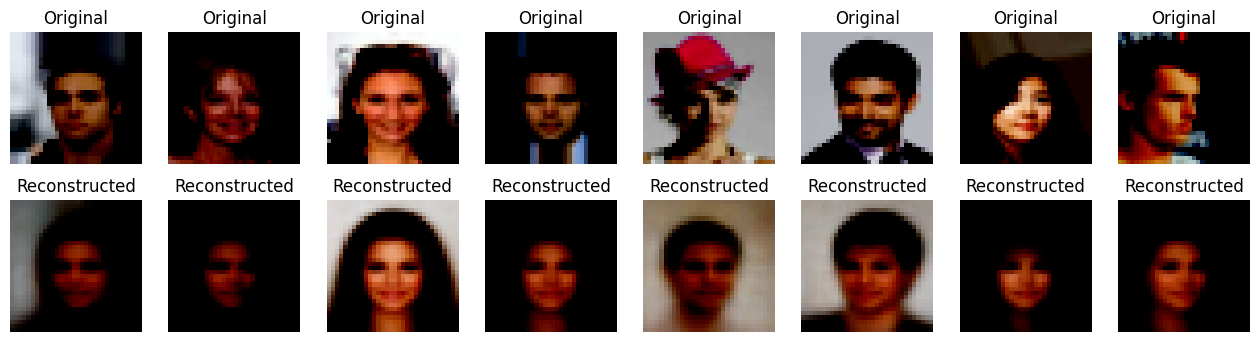

In [11]:
# Save the final model
os.makedirs("./models", exist_ok=True)
torch.save(model.state_dict(), "./models/vae_face.pt")

model.eval()

# Take a small batch to reconstruct
data_iter = iter(train_loader)
images, _ = next(data_iter)
images = images[:8].to(DEVICE)

with torch.no_grad():
    mu, logvar, recon,_ = model(images)

# Visualize original vs. reconstructions
def show_reconstructions(orig, recon):
    """
    Show original (top row) and reconstructions (bottom row).
    """
    n = orig.size(0)
    plt.figure(figsize=(2*n, 4))
    for i in range(n):
        # Original
        plt.subplot(2, n, i+1)
        plt.imshow(orig[i].permute(1,2,0).cpu().numpy())
        plt.title("Original")
        plt.axis("off")

    for i in range(n):
        # Recon
        plt.subplot(2, n, n+i+1)
        plt.imshow(recon[i].permute(1,2,0).detach().cpu().numpy())
        plt.title("Reconstructed")
        plt.axis("off")
    plt.show()

show_reconstructions(images, recon)

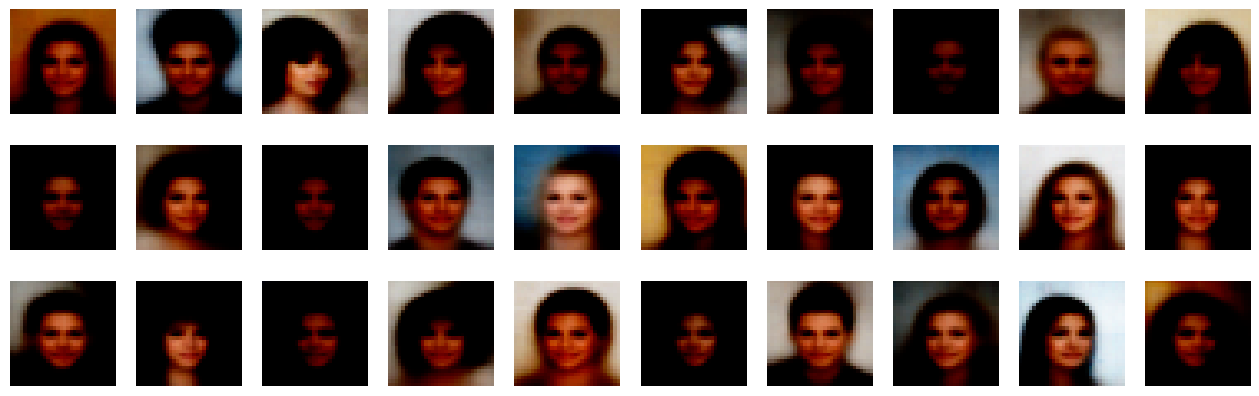

In [12]:
model.eval()

grid_width, grid_height = 10, 3
z_sample = torch.randn((grid_width*grid_height, Z_DIM)).to(DEVICE)

with torch.no_grad():
    recon = model.decoder(z_sample).detach()

# Plot the generated images
def show_generated(recon, w=grid_width, h=grid_height):
    recon = recon.cpu()
    fig = plt.figure(figsize=(16, 5))
    for i in range(w*h):
        ax = fig.add_subplot(h, w, i+1)
        ax.axis("off")
        ax.imshow(recon[i].permute(1,2,0).numpy())
    plt.show()

show_generated(recon)
